In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

def load_csv(path):
    d = pd.read_csv(path)
    d['video_name'] = d['video'].apply(
        lambda url: re.sub(r'_r\d+$', '', url.split('/')[-1].replace('.mp4', ''))
    )
    return d

df_pos = load_csv('position.csv')   # C1, C2
df_fac = load_csv('facing.csv')     # C3, C4

# Each bar is (label, video_name key, scene key matching two_dots_angles.ipynb)
conditions = [
    {
        'title': '1: Same 2D, Diff 3D position',
        'df': df_pos,
        'bars': [
            ('1a: Near\nin-plane',     'c11_c21_c31_c41_near_in_plane', 'near_in_plane'),
            ('1b: Near\nout-of-plane', 'c12_near_out_of_plane',         'near_out_of_plane'),
            ('1c: Far\nin-plane',      'c13_c23_far_in_plane',          'far_in_plane'),
            ('1d: Far\nout-of-plane',  'c14_far_out_of_plane',          'far_out_of_plane'),
        ],
    },
    {
        'title': '2: Same 3D, Diff 2D position',
        'df': df_pos,
        'bars': [
            ('2a: Near\ncam 0°',  'c11_c21_c31_c41_near_in_plane', 'near_cam0'),
            ('2b: Near\ncam 60°', 'c22_c42_near_cam60',            'near_cam60'),
            ('2c: Far\ncam 0°',   'c13_c23_far_in_plane',          'far_cam0'),
            ('2d: Far\ncam 60°',  'c24_far_cam60',                 'far_cam60'),
        ],
    },
    {
        'title': '3: Same 2D, Diff 3D facing',
        'df': df_fac,
        'bars': [
            ('3a: Facing\nflat',       'c11_c21_c31_c41_near_in_plane', 'facing_flat'),
            ('3b: Facing\ntilted',     'c32_facing_tilted',             'facing_tilted'),
            ('3c: Not-facing\nflat',   'c33_c43_notfacing_flat',        'notfacing_flat'),
            ('3d: Not-facing\ntilted', 'c34_notfacing_tilted',          'notfacing_tilted'),
        ],
    },
    {
        'title': '4: Same 3D, Diff 2D facing',
        'df': df_fac,
        'bars': [
            ('4a: Facing\ncam 0°',      'c11_c21_c31_c41_near_in_plane', 'facing_cam0'),
            ('4b: Facing\ncam 60°',     'c22_c42_near_cam60',            'facing_cam60'),
            ('4c: Not-facing\ncam 0°',  'c33_c43_notfacing_flat',        'notfacing_cam0'),
            ('4d: Not-facing\ncam 60°', 'c44_notfacing_cam60',           'notfacing_cam60'),
        ],
    },
]

print(f"position.csv: {len(df_pos)} rows, {df_pos['pid'].nunique()} participants")
print(f"facing.csv:   {len(df_fac)} rows, {df_fac['pid'].nunique()} participants")

position.csv: 360 rows, 20 participants
facing.csv:   360 rows, 20 participants


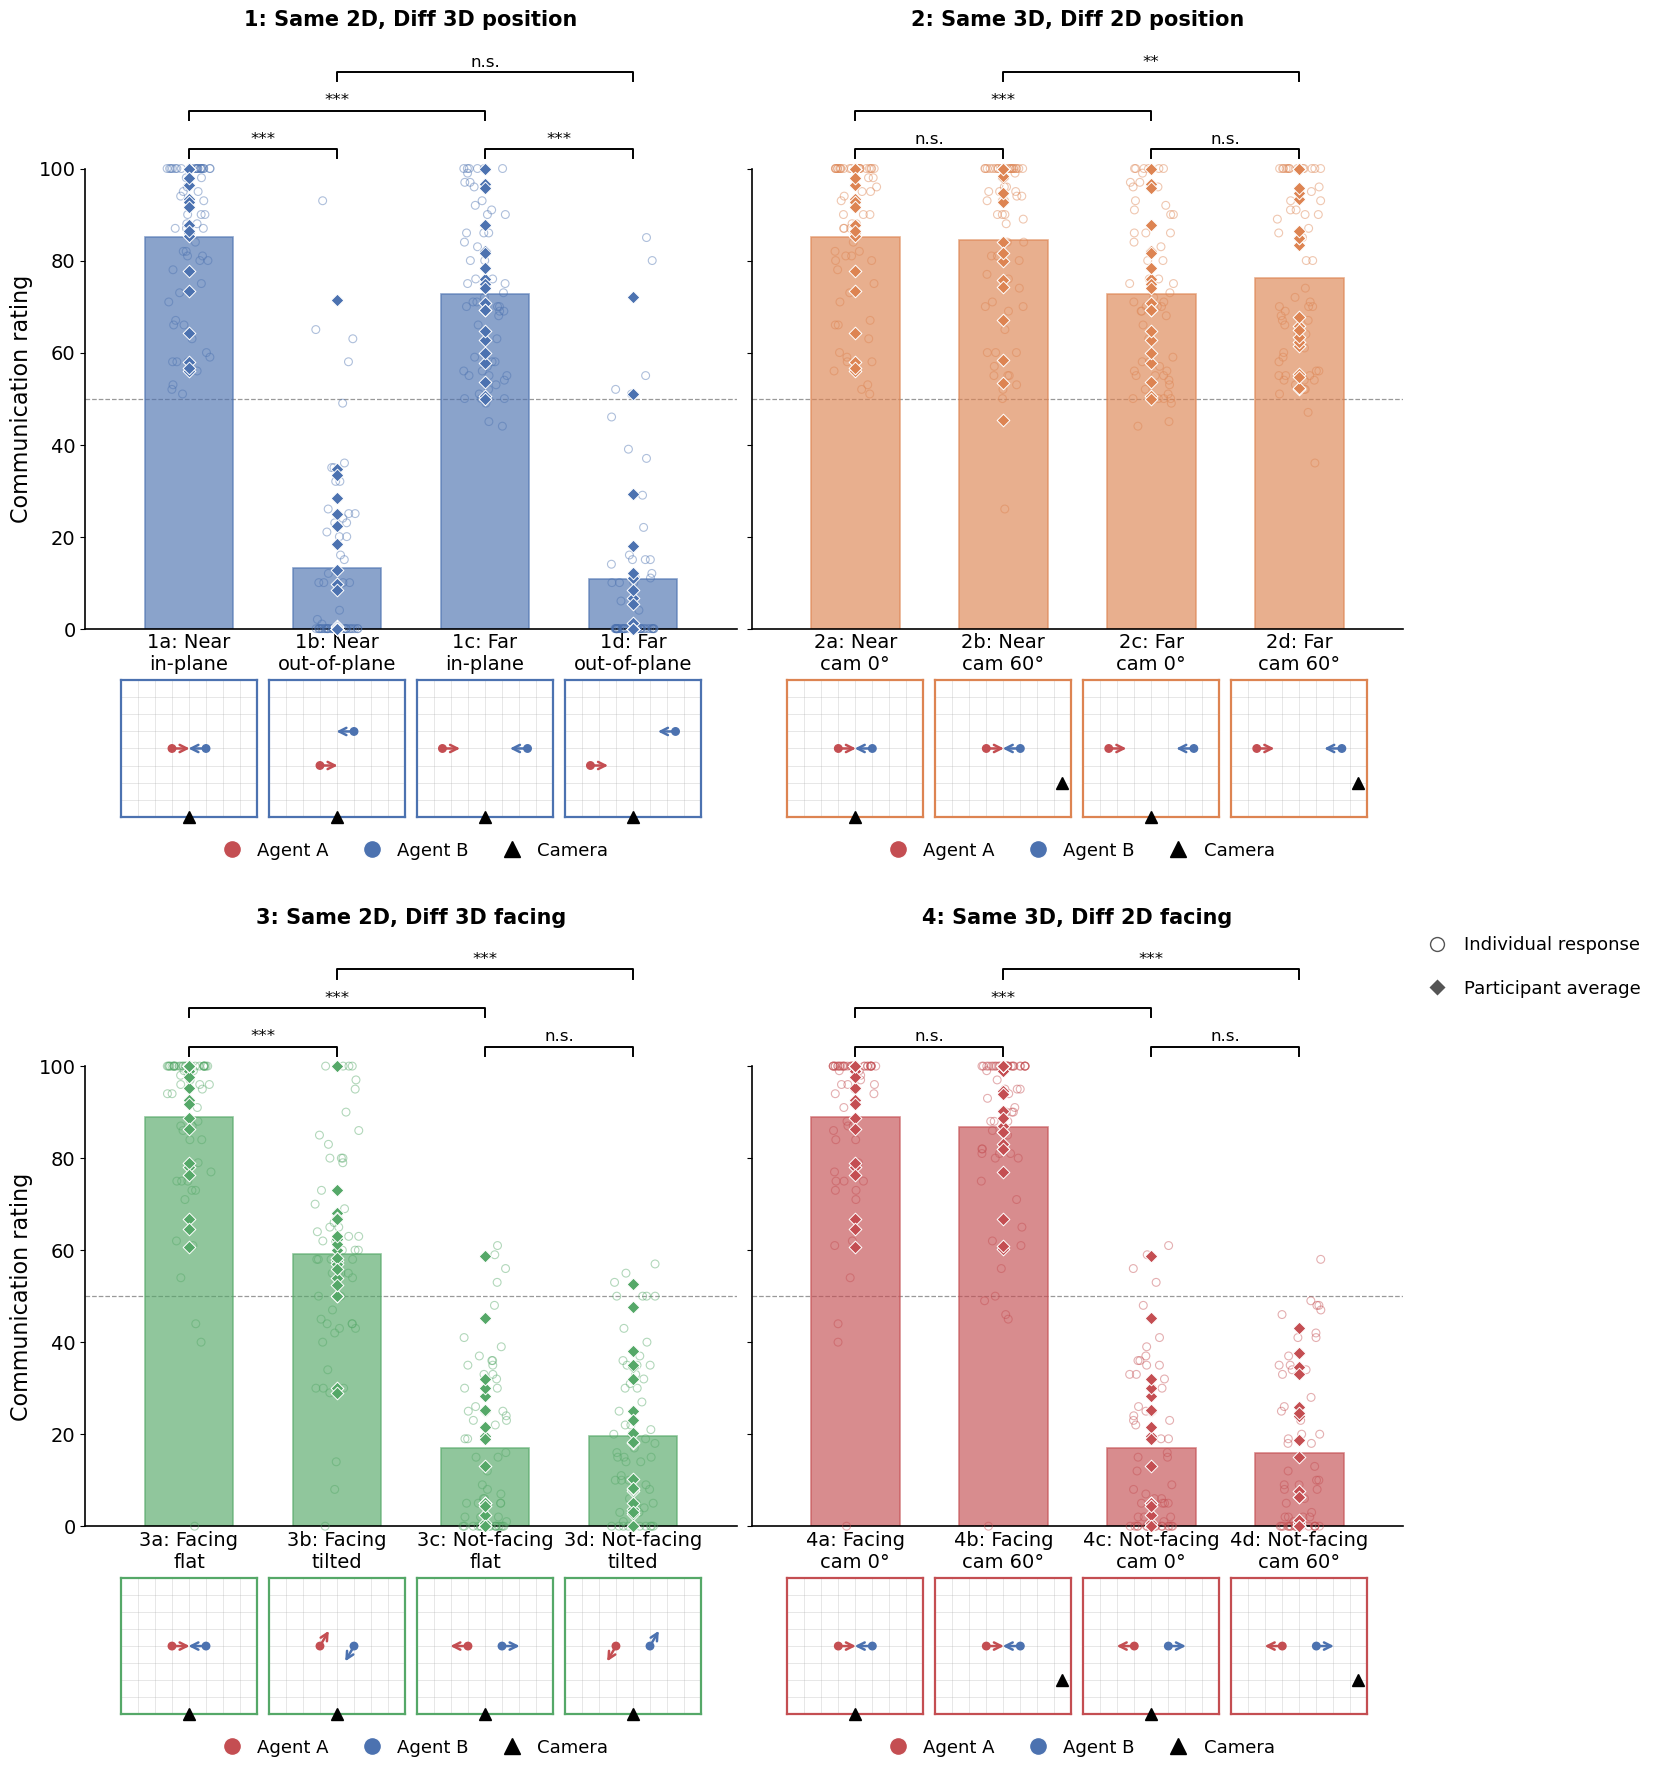

In [2]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

def paired_permutation_test(a, b, n_perm=10000, rng=None):
    """Paired sign-flip permutation test on participant-level means.

    a, b must be paired arrays (same length, same participant order) -
    e.g. one mean rating per participant per condition, since each
    participant rated every condition (3 reps each) in this design.
    """
    if rng is None:
        rng = np.random.default_rng(42)
    diffs = np.array(a) - np.array(b)
    observed = np.abs(diffs.mean())
    n = len(diffs)
    signs = rng.choice([-1, 1], size=(n_perm, n))
    perm_means = np.abs((diffs * signs).mean(axis=1))
    count = np.sum(perm_means >= observed)
    return observed, count / n_perm

PAIRS = [(0, 1), (0, 2), (1, 3), (2, 3)]

# Pre-compute all permutation tests
rng_perm = np.random.default_rng(0)
perm_results = {}
for cond in conditions:
    df = cond['df']
    bar_keys = [key for _, key, _ in cond['bars']]

    # raw per-rating values (all 3 reps), used only for plotting
    groups = [df[df['video_name'] == key]['q_communication'].values
              for _, key, _ in cond['bars']]

    # participant-level means (avg over 3 reps), one row per pid,
    # aligned across conditions since every participant saw every video
    pivot = (df.groupby(['pid', 'video_name'])['q_communication']
               .mean().unstack()[bar_keys])

    cond_res = {}
    pairs_done = []
    for i, j in PAIRS:
        a = pivot.iloc[:, i].values
        b = pivot.iloc[:, j].values
        diff, p = paired_permutation_test(a, b, n_perm=10000, rng=rng_perm)
        cond_res[(i, j)] = {'diff': diff, 'p': p}
        pairs_done.append((i, j))
    # BH FDR correction within condition
    if pairs_done:
        pvals = [cond_res[(i, j)]['p'] for i, j in pairs_done]
        _, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')
        for (i, j), p_fdr in zip(pairs_done, pvals_fdr):
            cond_res[(i, j)]['p_fdr'] = p_fdr
    perm_results[cond['title']] = cond_res


def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return None


# Tight bracket-stacking geometry (data units on the 0-100 rating scale) so
# the significance annotations sit close above the bars, paper-figure style.
BR_GAP, BR_TICK, BR_LPAD = 2.2, 2, 4.2


def bracket_height(pairs_with_p):
    """Compute max y height all brackets would occupy, without drawing."""
    if not pairs_with_p:
        return 100
    pwp = sorted(pairs_with_p, key=lambda x: (x[1] - x[0], x[0]))
    occupied = [100] * 4
    for i, j, _ in pwp:
        h = max(occupied[i:j + 1]) + BR_GAP
        for k in range(i, j + 1):
            occupied[k] = h + BR_TICK + BR_LPAD
    return max(occupied)


def add_sig_brackets(ax, pairs_with_p):
    """Draw brackets for all tested pairs; significant ones get stars, others n.s.
    Drawn with clip_on=False so they float above the axes' y=100 frame."""
    if not pairs_with_p:
        return 100
    pwp = sorted(pairs_with_p, key=lambda x: (x[1] - x[0], x[0]))

    occupied = [100] * 4

    for i, j, p in pwp:
        label = sig_stars(p) or 'n.s.'
        h = max(occupied[i:j + 1]) + BR_GAP
        ax.plot([i, i, j, j], [h, h + BR_TICK, h + BR_TICK, h],
                lw=1.4, color='black', clip_on=False)
        ax.text((i + j) / 2, h + BR_TICK + 0.6, label,
                ha='center', va='bottom', fontsize=12, clip_on=False)
        for k in range(i, j + 1):
            occupied[k] = h + BR_TICK + BR_LPAD

    return max(occupied)


# ── Two-dot scene illustrations (geometry copied from two_dots_angles.ipynb) ──
import matplotlib.gridspec as outer_gridspec
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

CAM_STD = np.array([0., 0.])
CAM_60  = np.array([2 * np.sqrt(3), 2.])

SCENES = {
    'near_in_plane':          dict(p1=[-1., 4.],  a1=0.,   p2=[1., 4.],  a2=180., camera=CAM_STD),
    'near_out_of_plane':      dict(p1=[-1., 3.],  a1=0.,   p2=[1., 5.],  a2=180., camera=CAM_STD),
    'far_in_plane':           dict(p1=[-2.5, 4.], a1=0.,   p2=[2.5, 4.], a2=180., camera=CAM_STD),
    'far_out_of_plane':       dict(p1=[-2.5, 3.], a1=0.,   p2=[2.5, 5.], a2=180., camera=CAM_STD),
    'near_cam60':             dict(p1=[-1., 4.],  a1=0.,   p2=[1., 4.],  a2=180., camera=CAM_60),
    'far_cam60':               dict(p1=[-2.5, 4.], a1=0.,   p2=[2.5, 4.], a2=180., camera=CAM_60),
    'facing_tilted':          dict(p1=[-1., 4.],  a1=60.,  p2=[1., 4.],  a2=240., camera=CAM_STD),
    'notfacing_flat':         dict(p1=[-1., 4.],  a1=180., p2=[1., 4.],  a2=0.,   camera=CAM_STD),
    'notfacing_tilted':       dict(p1=[-1., 4.],  a1=240., p2=[1., 4.],  a2=60.,  camera=CAM_STD),
    'notfacing_cam60':        dict(p1=[-1., 4.],  a1=180., p2=[1., 4.],  a2=0.,   camera=CAM_60),
}
SCENES['near_cam0']      = SCENES['near_in_plane']
SCENES['far_cam0']       = SCENES['far_in_plane']
SCENES['facing_flat']    = SCENES['near_in_plane']
SCENES['facing_cam0']    = SCENES['near_in_plane']
SCENES['facing_cam60']   = SCENES['near_cam60']
SCENES['notfacing_cam0'] = SCENES['notfacing_flat']


def draw_mini_scene(ax, scene_key, color, xlim=(-4, 4), ylim=(0, 8)):
    """Compact two-dot illustration (agent A=red, B=blue, camera=black triangle)."""
    s = SCENES[scene_key]
    p1, p2 = np.array(s['p1']), np.array(s['p2'])
    cx, cy = s['camera']
    ax.plot(cx, cy, 'k^', markersize=9, zorder=6, clip_on=False)
    ax.add_patch(Circle(p1, 0.22, color='#C44E52', zorder=3))
    ax.add_patch(Circle(p2, 0.22, color='#4C72B0', zorder=3))
    for pos, angle, c in [(p1, s['a1'], '#C44E52'), (p2, s['a2'], '#4C72B0')]:
        d = np.array([np.cos(np.radians(angle)), np.sin(np.radians(angle))])
        ax.annotate('', xy=pos + d * 1.2, xytext=pos,
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.8, mutation_scale=13),
                    zorder=4)
    ax.set_aspect('equal')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 1))
    ax.tick_params(labelbottom=False, labelleft=False, length=0)
    ax.grid(True, alpha=0.35, linewidth=0.6)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(1.6)


colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
rng = np.random.default_rng(42)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C44E52', markersize=13, label='Agent A'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=13, label='Agent B'),
    Line2D([0], [0], marker='^', color='k', linestyle='None', markersize=12, label='Camera'),
]

# Uniform title y across all conditions (based on tallest bracket stack)
all_pairs_with_p = [
    [(i, j, perm_results[cond['title']][(i, j)]['p_fdr'])
     for (i, j) in PAIRS if (i, j) in perm_results[cond['title']]]
    for cond in conditions
]
title_y = max(bracket_height(pwp) for pwp in all_pairs_with_p) + 5

# 2x2 grid of condition blocks (top row: C1, C2 | bottom row: C3, C4).
# Each block = bar chart, then (tightly below) a row of 4 mini scene
# illustrations, then its own small dot legend. A blank spacer row sits
# between the two condition rows so the sig-bracket overshoot above the
# C3/C4 charts, PLUS the C1/C2 legend below the illustration row, both
# have room without colliding with each other.
fig = plt.figure(figsize=(17, 21))
outer = outer_gridspec.GridSpec(5, 8, figure=fig,
                                 height_ratios=[5, 3.2, 2.7, 5, 3.2],
                                 hspace=-0.1, wspace=0.1)

block_pos = [(0, 0), (0, 4), (3, 0), (3, 4)]  # (row, col) of top-left cell per condition

plt.rcParams['font.size'] = 11

# Reserved figure-fraction gap below each bar axes for its two-line x-tick
# labels, before the illustration boxes start.
LABEL_GAP = 0.01

bar_axes = []
for cond, color, pairs_with_p, (r0, c0) in zip(conditions, colors, all_pairs_with_p, block_pos):
    df = cond['df']
    groups = [df[df['video_name'] == key]['q_communication'].values
              for _, key, _ in cond['bars']]

    ax = fig.add_subplot(outer[r0, c0:c0 + 4])
    bar_axes.append(ax)

    for i, (label, video_key, scene_key) in enumerate(cond['bars']):
        subset = groups[i]
        mean_val = subset.mean() if len(subset) > 0 else 0

        ax.bar(i, mean_val, color=color, alpha=0.65, width=0.6,
               edgecolor=color, linewidth=1.2, zorder=2)
        if len(subset) > 0:
            # individual ratings (all 3 reps): light, jittered open circles
            jitter = rng.uniform(-0.15, 0.15, len(subset))
            ax.scatter(i + jitter, subset,
                       facecolors='none', edgecolors=color, alpha=0.45,
                       s=32, linewidths=0.8, zorder=3, clip_on=False)

            # participant-level averages (3 reps collapsed to 1 point per
            # participant): solid diamonds, not jittered
            pid_means = (df[df['video_name'] == video_key]
                         .groupby('pid')['q_communication'].mean().values)
            ax.scatter(np.full(len(pid_means), i), pid_means,
                       marker='D', color=color, s=42, zorder=4,
                       edgecolors='white', linewidths=0.7, clip_on=False)

    add_sig_brackets(ax, pairs_with_p)

    ax.text(1.5, title_y, cond['title'],
            ha='center', va='bottom', fontsize=15, fontweight='bold', clip_on=False)

    ax.set_xticks(np.arange(4))
    ax.set_xticklabels([lbl for lbl, _, _ in cond['bars']], fontsize=14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(1.2)
    ax.axhline(50, color='#999999', linewidth=0.9, linestyle='--', zorder=1)
    ax.set_xlim(-0.7, 3.7)
    ax.set_ylim(0, 100)
    ax.set_yticks(range(0, 101, 20))
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', length=0, pad=3)
    if c0 == 0:
        ax.set_ylabel('Communication rating', fontsize=16)
    else:
        ax.tick_params(labelleft=False)

    # Row of mini scene illustrations, individually centered under each bar's
    # x position (computed in figure coordinates so they line up exactly
    # with the tick even though the bar axes has left/right margin). A
    # LABEL_GAP is reserved at the top of the row so the two-line x-tick
    # labels ("Near\nin-plane") don't collide with the illustration boxes.
    illus_row = r0 + 1
    row_bbox = outer[illus_row, c0:c0 + 4].get_position(fig)
    tick_disp = ax.transData.transform(np.column_stack([np.arange(4), np.zeros(4)]))
    tick_fig_x = fig.transFigure.inverted().transform(tick_disp)[:, 0]
    spacing = np.min(np.diff(tick_fig_x))
    box_w = spacing * 0.92
    box_top = row_bbox.y1 - LABEL_GAP
    box_h = max(box_top - row_bbox.y0, 0.01) * 0.98
    y_center = box_top - box_h / 2
    for i, (label, video_key, scene_key) in enumerate(cond['bars']):
        iax = fig.add_axes([tick_fig_x[i] - box_w / 2, y_center - box_h / 2, box_w, box_h])
        draw_mini_scene(iax, scene_key, color)

    # Small dot legend directly under this block's illustration row.
    row_center_x = (row_bbox.x0 + row_bbox.x1) / 2
    fig.legend(handles=legend_elements, loc='upper center',
               bbox_to_anchor=(row_center_x, row_bbox.y0 + 0.03),
               bbox_transform=fig.transFigure,
               ncol=3, frameon=False, fontsize=13, handletextpad=0.4, columnspacing=1.4)

# Marker-meaning legend (circle = individual response, diamond = participant
# average), placed once to the right of the whole figure.
dot_legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='#555555', markersize=10, label='Individual response'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#555555',
           markeredgecolor='white', markersize=9, label='Participant average'),
]
fig.legend(handles=dot_legend_elements, loc='center left',
           bbox_to_anchor=(0.9, 0.5), bbox_transform=fig.transFigure,
           frameon=False, fontsize=13, handletextpad=0.5, labelspacing=1.4)

plt.savefig('responses_by_condition.png', dpi=200, bbox_inches='tight')
plt.show()

In [3]:
# Display permutation test results as a table (uses perm_results computed in the plot cell)
rows = []
for cond in conditions:
    df = cond['df']
    bar_labels = [lbl.replace('\n', ' ') for lbl, _, _ in cond['bars']]
    groups = [df[df['video_name'] == key]['q_communication'].values
              for _, key, _ in cond['bars']]
    cond_perm = perm_results[cond['title']]
    for i, j in PAIRS:
        if (i, j) not in cond_perm:
            continue
        a, b = groups[i], groups[j]
        r = cond_perm[(i, j)]
        rows.append({
            'Condition':  cond['title'],
            'Group A':    bar_labels[i],
            'Group B':    bar_labels[j],
            'n (participants)': df['pid'].nunique(),
            'Mean A': round(a.mean(), 2),
            'Mean B': round(b.mean(), 2),
            'Diff':   round(r['diff'], 2),
            'p-value':    round(r['p'], 4),
            'p (BH FDR)': round(r['p_fdr'], 4),
        })

results_df = pd.DataFrame(rows)
results_df['sig (raw)']    = results_df['p-value'].apply(
    lambda v: '***' if v < .001 else ('**' if v < .01 else ('*' if v < .05 else 'ns')))
results_df['sig (BH FDR)'] = results_df['p (BH FDR)'].apply(
    lambda v: '***' if v < .001 else ('**' if v < .01 else ('*' if v < .05 else 'ns')))

print("Paired sign-flip permutation test on participant-level means (3 reps averaged per participant)")
print("10,000 permutations, two-sided | BH FDR × 4 within condition | n=20 participants")
print("* p<.05  ** p<.01  *** p<.001\n")
display(results_df)

Paired sign-flip permutation test on participant-level means (3 reps averaged per participant)
10,000 permutations, two-sided | BH FDR × 4 within condition | n=20 participants
* p<.05  ** p<.01  *** p<.001



,Condition,Group A,Group B,n (participants),Mean A,Mean B,Diff,p-value,p (BH FDR),sig (raw),sig (BH FDR)
0,"1: Same 2D, Diff 3D position",1a: Near in-plane,1b: Near out-of-plane,20,85.17,13.25,71.92,0.0000,0.0000,***,***
1,"1: Same 2D, Diff 3D position",1a: Near in-plane,1c: Far in-plane,20,85.17,72.78,12.38,0.0001,0.0001,***,***
2,"1: Same 2D, Diff 3D position",1b: Near out-of-plane,1d: Far out-of-plane,20,13.25,10.75,2.50,0.2223,0.2223,ns,ns
3,"1: Same 2D, Diff 3D position",1c: Far in-plane,1d: Far out-of-plane,20,72.78,10.75,62.03,0.0000,0.0000,***,***
4,"2: Same 3D, Diff 2D position",2a: Near cam 0°,2b: Near cam 60°,20,85.17,84.48,0.68,0.8441,0.8441,ns,ns
5,"2: Same 3D, Diff 2D position",2a: Near cam 0°,2c: Far cam 0°,20,85.17,72.78,12.38,0.0001,0.0004,***,***
6,"2: Same 3D, Diff 2D position",2b: Near cam 60°,2d: Far cam 60°,20,84.48,76.15,8.33,0.0014,0.0028,**,**
7,"2: Same 3D, Diff 2D position",2c: Far cam 0°,2d: Far cam 60°,20,72.78,76.15,3.37,0.2497,0.3329,ns,ns
8,"3: Same 2D, Diff 3D facing",3a: Facing flat,3b: Facing tilted,20,88.83,59.18,29.65,0.0000,0.0000,***,***
9,"3: Same 2D, Diff 3D facing",3a: Facing flat,3c: Not-facing flat,20,88.83,17.02,71.82,0.0000,0.0000,***,***


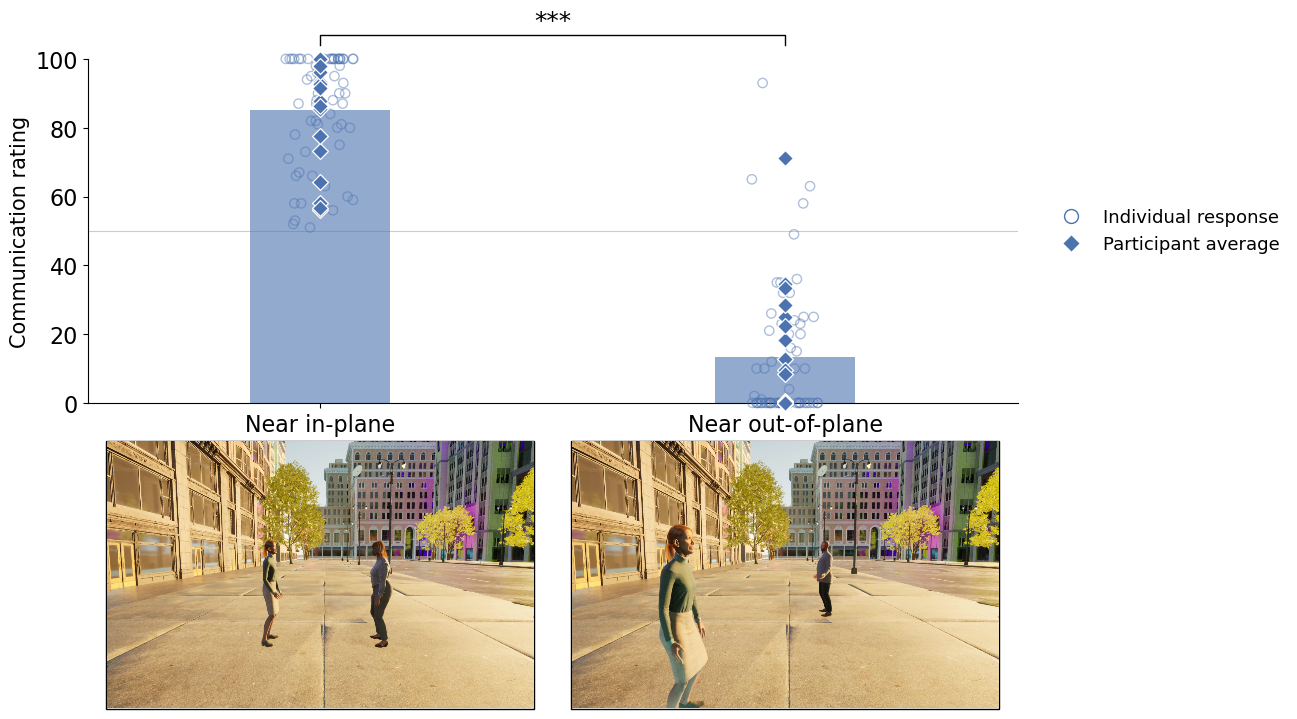

In [4]:
import cv2
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.lines import Line2D

def get_middle_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None

frame_in  = get_middle_frame('videos/c11_c21_c31_c41_near_in_plane_r1.mp4')
frame_out = get_middle_frame('videos/c12_near_out_of_plane_r1.mp4')

# Data for the two bars
df = conditions[0]['df']
keys   = ['c11_c21_c31_c41_near_in_plane', 'c12_near_out_of_plane']
labels = ['Near in-plane', 'Near out-of-plane']
groups = [df[df['video_name'] == k]['q_communication'].values for k in keys]
xpos   = [0, 2]

p_fdr  = perm_results['1: Same 2D, Diff 3D position'][(0, 1)]['p_fdr']
bracket_label = sig_stars(p_fdr) or 'n.s.'

IMG_ZOOM   = 0.12
IMG_YSHIFT = -0.5

color = '#4C72B0'
rng2  = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(12, 8))
fig.subplots_adjust(bottom=0.45)

for xi, k, subset, lbl in zip(xpos, keys, groups, labels):
    ax.bar(xi, subset.mean(), color=color, alpha=0.6, width=0.6, zorder=2)

    # individual ratings (all 3 reps): light, jittered open circles
    jitter = rng2.uniform(-0.15, 0.15, len(subset))
    ax.scatter(xi + jitter, subset,
               facecolors='none', edgecolors=color, alpha=0.45,
               s=45, linewidths=1.0, zorder=3, clip_on=False)

    # participant-level averages (3 reps collapsed to 1 point per
    # participant): solid diamonds, not jittered
    pid_means = df[df['video_name'] == k].groupby('pid')['q_communication'].mean().values
    ax.scatter(np.full(len(pid_means), xi), pid_means,
               marker='D', color=color, s=65, zorder=4,
               edgecolors='white', linewidths=0.9, clip_on=False)

# Significance bracket
h, tick = 104, 3
x0, x1 = xpos
ax.plot([x0, x0, x1, x1], [h, h+tick, h+tick, h], lw=1.0, color='black', clip_on=False)
ax.text((x0+x1)/2, h+tick+0.5, bracket_label,
        ha='center', va='bottom', fontsize=18, clip_on=False)

ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 20))
ax.set_xlim(-1, 3)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylabel('Communication rating', fontsize=15)
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(50, color='#cccccc', linewidth=0.8, zorder=1)

# Marker-meaning legend, placed outside the axes to the right, vertically centered.
dot_legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor=color, markersize=10, label='Individual response'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=color,
           markeredgecolor='white', markersize=9, label='Participant average'),
]
ax.legend(handles=dot_legend_elements, loc='center left',
          bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=13)

for xi, frame in zip(xpos, [frame_in, frame_out]):
    if frame is not None:
        imagebox = OffsetImage(frame, zoom=IMG_ZOOM)
        ab = AnnotationBbox(imagebox, xy=(xi, IMG_YSHIFT),
                            xycoords=('data', 'axes fraction'),
                            frameon=True, pad=0.05,
                            annotation_clip=False)
        ax.add_artist(ab)

plt.savefig('c1_near_comparison.png', dpi=300, bbox_inches='tight')
plt.show()